# Micro Proyecto 2: Clasificacion de textos segun los Objetivos de Desarrollo Sostenible (ODS)

**Integrantes**: Erick Cubas Vigo y Santiago Giraldo Ardila  
**Objetivo:** Desarrollar una solucion basada en tecnicas de procesamiento de lenguaje natural (NLP) y machine learning que permita clasificar automaticamente textos en español segun los 16 Objetivos de Desarrollo Sostenible (ODS) de la ONU.

**Enfoque del proyecto:**
1. Preparacion y limpieza de textos en español mediante un pipeline de procesamiento.
2. Representacion vectorial de los textos usando dos enfoques: **TF-IDF** (Bolsa de Palabras) y **Word2Vec** (embeddings semanticos).
3. Reduccion de dimensionalidad con la tecnica adecuada para cada representacion: **TruncatedSVD** para TF-IDF (matrices dispersas) y **PCA** para Word2Vec (embeddings densos). Se justifica por que las combinaciones cruzadas no son apropiadas.
4. Construccion y comparacion de **2 algoritmos de clasificacion**: Regresion Logistica y SVM.
5. Busqueda de hiperparametros y evaluacion con metricas adecuadas.
6. Demostracion del desempeno con textos del conjunto de prueba.

## 1. Configuracion del entorno e importacion de librerias

**Justificacion:** Importamos todas las librerias necesarias al inicio para tener una vision clara de las dependencias del proyecto. Cada libreria cumple un rol especifico:
- **pandas/numpy**: manipulacion de datos y operaciones numericas.
- **matplotlib/seaborn**: visualizacion de datos y resultados.
- **sklearn**: pipeline de preprocesamiento, vectorizacion TF-IDF, reduccion de dimensionalidad, modelos de clasificacion y metricas de evaluacion.
- **nltk**: lista de stopwords en español y herramientas de procesamiento de texto.
- **gensim**: entrenamiento del modelo Word2Vec para representacion semantica de palabras.
- **re**: expresiones regulares para limpieza de texto.
- **joblib**: serializacion del modelo final para despliegue.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['PYTHONWARNINGS'] = 'ignore'

import logging
logging.getLogger('gensim').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

# Sklearn - Preprocesamiento y Vectorizacion
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder

# Sklearn - Reduccion de dimensionalidad
from sklearn.decomposition import TruncatedSVD, PCA

# Sklearn - Modelos de clasificacion
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Sklearn - Metricas
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, ConfusionMatrixDisplay)

# Word2Vec
from gensim.models import Word2Vec

# Serializacion
import joblib

# Descargar recursos NLTK
nltk.download('stopwords', quiet=True)

# Configuracion de visualizacion
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerias cargadas correctamente.")

Librerias cargadas correctamente.


## 2. Carga y exploracion del conjunto de datos

**Justificacion:** Antes de cualquier transformacion, es fundamental entender la estructura y caracteristicas del dataset. Esto nos permite identificar posibles problemas (datos faltantes, desbalance de clases, textos muy cortos o muy largos) y tomar decisiones informadas en los pasos siguientes.

In [2]:
# Cargar el dataset
df = pd.read_excel('data.xlsx')

print(f"Dimensiones del dataset: {df.shape}")
print(f"Columnas: {list(df.columns)}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nPrimeras 3 filas:")
df.head(3)

Dimensiones del dataset: (9656, 2)
Columnas: ['textos', 'ODS']

Tipos de datos:
textos    object
ODS        int64
dtype: object

Valores nulos:
textos    0
ODS       0
dtype: int64

Primeras 3 filas:


,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13


In [3]:
# Diccionario de nombres de los ODS
ODS_NOMBRES = {
    1: "Fin de la pobreza",
    2: "Hambre cero",
    3: "Salud y bienestar",
    4: "Educacion de calidad",
    5: "Igualdad de genero",
    6: "Agua limpia y saneamiento",
    7: "Energia asequible y no contaminante",
    8: "Trabajo decente y crecimiento economico",
    9: "Industria, innovacion e infraestructura",
    10: "Reduccion de las desigualdades",
    11: "Ciudades y comunidades sostenibles",
    12: "Produccion y consumo responsables",
    13: "Accion por el clima",
    14: "Vida submarina",
    15: "Vida de ecosistemas terrestres",
    16: "Paz, justicia e instituciones solidas"
}

# Distribucion de clases
print("Distribucion de textos por ODS:\n")
distribucion = df['ODS'].value_counts().sort_index()
for ods, count in distribucion.items():
    print(f"  ODS {ods:2d} - {ODS_NOMBRES[ods]:45s} | {count:4d} textos")
print(f"\n  {'Total':50s} | {len(df):4d} textos")

Distribucion de textos por ODS:

  ODS  1 - Fin de la pobreza                             |  505 textos
  ODS  2 - Hambre cero                                   |  369 textos
  ODS  3 - Salud y bienestar                             |  894 textos
  ODS  4 - Educacion de calidad                          | 1025 textos
  ODS  5 - Igualdad de genero                            | 1070 textos
  ODS  6 - Agua limpia y saneamiento                     |  695 textos
  ODS  7 - Energia asequible y no contaminante           |  787 textos
  ODS  8 - Trabajo decente y crecimiento economico       |  446 textos
  ODS  9 - Industria, innovacion e infraestructura       |  343 textos
  ODS 10 - Reduccion de las desigualdades                |  352 textos
  ODS 11 - Ciudades y comunidades sostenibles            |  607 textos
  ODS 12 - Produccion y consumo responsables             |  312 textos
  ODS 13 - Accion por el clima                           |  464 textos
  ODS 14 - Vida submarina                   

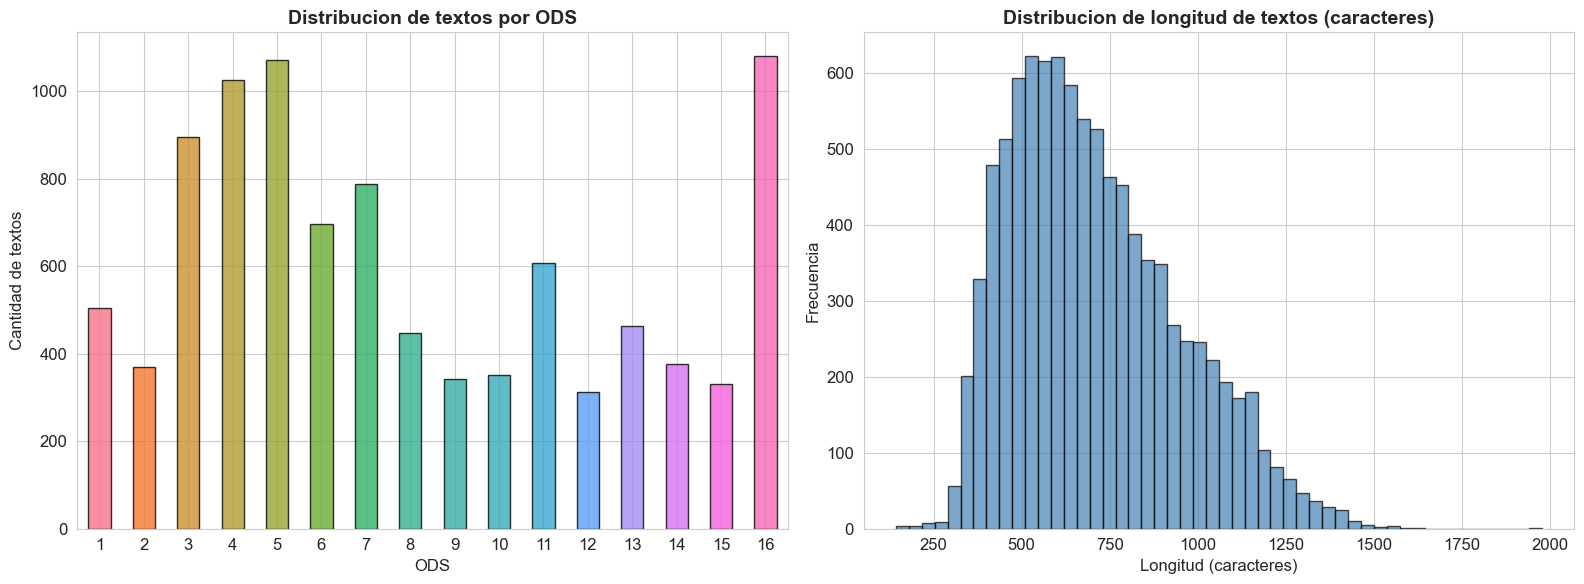


Estadisticas de longitud de textos:
  Promedio: 709 caracteres
  Minimo:   143 caracteres
  Maximo:   1977 caracteres
  Mediana:  669 caracteres


In [4]:
# Visualizacion de la distribucion de clases
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafico de barras
colors = sns.color_palette("husl", n_colors=16)
distribucion.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Distribucion de textos por ODS', fontsize=14, fontweight='bold')
axes[0].set_xlabel('ODS')
axes[0].set_ylabel('Cantidad de textos')
axes[0].tick_params(axis='x', rotation=0)

# Estadisticas de longitud de texto
df['longitud'] = df['textos'].str.len()
df['longitud'].hist(bins=50, ax=axes[1], color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribucion de longitud de textos (caracteres)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Longitud (caracteres)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f"\nEstadisticas de longitud de textos:")
print(f"  Promedio: {df['longitud'].mean():.0f} caracteres")
print(f"  Minimo:   {df['longitud'].min()} caracteres")
print(f"  Maximo:   {df['longitud'].max()} caracteres")
print(f"  Mediana:  {df['longitud'].median():.0f} caracteres")

## 3. Pipeline de preprocesamiento de texto

**Justificacion de cada paso del pipeline:**

1. **Conversion a minusculas:** Unificamos la representacion para que "Pobreza" y "pobreza" se traten como la misma palabra, reduciendo la dimensionalidad del vocabulario.
2. **Eliminacion de caracteres especiales, numeros y puntuacion:** Estos elementos generalmente no aportan informacion semantica relevante para la clasificacion por ODS y generan ruido en la representacion vectorial.
3. **Tokenizacion:** Dividimos el texto en palabras individuales (tokens) para poder procesarlas de forma independiente.
4. **Eliminacion de stopwords en español:** Palabras como "de", "la", "que", "en" son muy frecuentes pero no discriminan entre categorias. Su eliminacion reduce el ruido y la dimensionalidad.
5. **Stemming (SnowballStemmer para español):** Reducimos las palabras a su raiz (e.g., "educacion", "educativo", "educar" -> "educ"), lo cual agrupa variantes morfologicas y reduce la dimension del vocabulario. Usamos SnowballStemmer porque soporta español de forma nativa.

**Sobre la construccion como Pipeline de sklearn:** Encapsulamos el preprocesamiento como un `TransformerMixin` compatible con sklearn. Esto permite integrarlo limpiamente en pipelines, garantiza reproducibilidad y facilita el despliegue posterior (e.g., en Streamlit).

In [5]:
# Constantes de preprocesamiento (definidas a nivel de modulo para evitar problemas de pickle
# con nltk.corpus.stopwords, que no es serializable en Python 3.13)
SPANISH_STOP_WORDS = frozenset(stopwords.words('spanish'))
SPANISH_STEMMER_CACHE = {}

def _stem_word(word):
    """Stemming con cache para evitar re-computar raices ya conocidas."""
    if word not in SPANISH_STEMMER_CACHE:
        SPANISH_STEMMER_CACHE[word] = SnowballStemmer('spanish').stem(word)
    return SPANISH_STEMMER_CACHE[word]


class TextPreprocessor(BaseEstimator, TransformerMixin):
    """
    Transformador personalizado de sklearn para preprocesar textos en español.
    Aplica: minusculas -> eliminacion de caracteres especiales -> tokenizacion ->
    eliminacion de stopwords -> stemming.
    
    Usa constantes a nivel de modulo (SPANISH_STOP_WORDS) en vez de objetos NLTK
    como atributos, para garantizar compatibilidad con pickle y n_jobs=-1.
    """
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return [self._preprocess(text) for text in X]

    @staticmethod
    def _preprocess(text):
        # 1. Convertir a minusculas
        text = text.lower()
        # 2. Eliminar caracteres especiales, numeros y puntuacion (conservar solo letras y espacios)
        text = re.sub(r'[^a-záéíóúüñ\s]', '', text)
        # 3. Tokenizar (dividir por espacios)
        tokens = text.split()
        # 4. Eliminar stopwords y 5. Aplicar stemming
        tokens = [_stem_word(word) for word in tokens
                  if word not in SPANISH_STOP_WORDS and len(word) > 2]
        return ' '.join(tokens)

# Instanciar y probar el preprocesador
preprocessor = TextPreprocessor()

# Ejemplo con un texto del dataset
ejemplo_original = df['textos'].iloc[0]
ejemplo_procesado = preprocessor.transform([ejemplo_original])[0]

print("EJEMPLO DE PREPROCESAMIENTO")
print("=" * 80)
print(f"\nTexto original (primeros 300 chars):\n{ejemplo_original[:300]}...")
print(f"\nTexto procesado (primeros 300 chars):\n{ejemplo_procesado[:300]}...")

EJEMPLO DE PREPROCESAMIENTO

Texto original (primeros 300 chars):
"Aprendizaje" y "educación" se consideran sinónimos de escolarización formal. Las organizaciones auxiliares, como las editoriales de educación, las juntas examinadoras y las organizaciones de formación de docentes, se consideran extensiones de los acuerdos establecidos por los gobiernos. Este marco ...

Texto procesado (primeros 300 chars):
aprendizaj educ consider sinon escolariz formal organiz auxiliar editorial educ junt examin organiz formacion docent consider extension acuerd establec gobi marc comprension vuelt cad vez inadecu...


In [6]:
# Separar variable objetivo (los textos crudos se partiran en la Seccion 4)
y = df['ODS'].values
print(f"Variable objetivo: {len(y)} etiquetas, {len(np.unique(y))} clases (ODS 1-16)")

Variable objetivo: 9656 etiquetas, 16 clases (ODS 1-16)


## 4. Division del conjunto de datos (Train/Test Split)

**Justificacion:** Dividimos el dataset en 80% entrenamiento y 20% prueba usando `stratify=y` para preservar la proporcion de cada clase ODS en ambos conjuntos. Esto es especialmente importante dado el desbalance de clases observado (ODS 12 tiene ~312 textos vs ODS 16 con ~1080). Sin estratificacion, las clases minoritarias podrian quedar subrepresentadas en el conjunto de prueba, generando evaluaciones poco fiables.

In [7]:
# Division estratificada 80/20 con textos crudos (sin preprocesar).
# Justificacion: el pipeline de la Seccion 7 integra el preprocesamiento internamente,
# asi que partimos del texto original para que el flujo sea end-to-end.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['textos'].values, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Conjunto de entrenamiento: {len(X_train_raw)} textos")
print(f"Conjunto de prueba:        {len(X_test_raw)} textos")
print(f"\nDistribucion en entrenamiento:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  ODS {u:2d}: {c:4d} ({c/len(y_train)*100:.1f}%)")

Conjunto de entrenamiento: 7724 textos
Conjunto de prueba:        1932 textos

Distribucion en entrenamiento:
  ODS  1:  404 (5.2%)
  ODS  2:  295 (3.8%)
  ODS  3:  715 (9.3%)
  ODS  4:  820 (10.6%)
  ODS  5:  856 (11.1%)
  ODS  6:  556 (7.2%)
  ODS  7:  629 (8.1%)
  ODS  8:  357 (4.6%)
  ODS  9:  274 (3.5%)
  ODS 10:  282 (3.7%)
  ODS 11:  485 (6.3%)
  ODS 12:  250 (3.2%)
  ODS 13:  371 (4.8%)
  ODS 14:  302 (3.9%)
  ODS 15:  264 (3.4%)
  ODS 16:  864 (11.2%)


## 5. Representacion vectorial de textos (analisis exploratorio)

> **Nota:** Las celdas de esta seccion y la Seccion 6 realizan un **analisis exploratorio** de las representaciones vectoriales y la reduccion de dimensionalidad. Este analisis sirve para entender los datos y justificar las decisiones de diseno. El entrenamiento real de los modelos utiliza los **Pipelines completos** definidos en la Seccion 7, que integran todas las transformaciones de extremo a extremo (texto crudo -> prediccion).

Utilizamos dos enfoques complementarios para convertir los textos en vectores numericos que los algoritmos de ML puedan procesar:

### 5a. TF-IDF (Term Frequency - Inverse Document Frequency)

**Justificacion:** TF-IDF es el enfoque clasico de Bolsa de Palabras (BoW) con pesado inteligente. A diferencia de un conteo simple de frecuencias, TF-IDF penaliza las palabras que aparecen en muchos documentos (como terminos genericos) y premia las palabras distintivas de cada documento. Esto es ideal para clasificacion de textos porque realza los terminos que realmente diferencian un ODS de otro.

Configuramos `max_features=10000` para limitar el vocabulario a las 10,000 palabras mas informativas, controlando la dimensionalidad. Usamos `sublinear_tf=True` para aplicar escalado logaritmico a la frecuencia de terminos, lo que reduce el impacto de palabras repetitivas dentro de un mismo texto.

In [8]:
# Preprocesamiento para analisis exploratorio (no usado en entrenamiento — el pipeline lo maneja)
# Necesario para alimentar las celdas exploratorias de TF-IDF, Word2Vec y varianza.
X_train_preprocessed = preprocessor.transform(X_train_raw)
X_test_preprocessed = preprocessor.transform(X_test_raw)
print(f"Textos preprocesados para exploracion: {len(X_train_preprocessed)} train, {len(X_test_preprocessed)} test")

Textos preprocesados para exploracion: 7724 train, 1932 test


In [9]:
# Vectorizacion TF-IDF (exploratorio — el pipeline de la Seccion 7 lo integra automaticamente)
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    sublinear_tf=True,       # Escalado logaritmico de TF
    ngram_range=(1, 2),      # Unigramas y bigramas para capturar frases relevantes
    min_df=3,                # Ignorar terminos que aparecen en menos de 3 documentos
    max_df=0.95              # Ignorar terminos que aparecen en mas del 95% de documentos
)

# Ajustar solo con datos de entrenamiento preprocesados para evitar data leakage
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_preprocessed)
X_test_tfidf = tfidf_vectorizer.transform(X_test_preprocessed)

print(f"Matriz TF-IDF de entrenamiento: {X_train_tfidf.shape}")
print(f"Matriz TF-IDF de prueba:        {X_test_tfidf.shape}")
print(f"Tipo de matriz: {type(X_train_tfidf).__name__} (dispersa/sparse)")
print(f"\nEjemplo - 10 palabras con mayor IDF (mas discriminativas):")
feature_names = tfidf_vectorizer.get_feature_names_out()
idf_scores = tfidf_vectorizer.idf_
top_idf_idx = np.argsort(idf_scores)[-10:]
for idx in top_idf_idx:
    print(f"  '{feature_names[idx]}': IDF = {idf_scores[idx]:.3f}")

Matriz TF-IDF de entrenamiento: (7724, 10000)
Matriz TF-IDF de prueba:        (1932, 10000)
Tipo de matriz: csr_matrix (dispersa/sparse)

Ejemplo - 10 palabras con mayor IDF (mas discriminativas):
  'lfpr': IDF = 8.566
  'esteriliz': IDF = 8.566
  'leds': IDF = 8.566
  'kazaj': IDF = 8.566
  'jpy': IDF = 8.566
  'relacion drog': IDF = 8.566
  'relacion preci': IDF = 8.566
  'vre': IDF = 8.566
  'ontolog': IDF = 8.566
  'delit cibernet': IDF = 8.566


### 5b. Word2Vec (Embeddings semanticos)

**Justificacion:** A diferencia de TF-IDF (que trata cada palabra como una dimension independiente), Word2Vec aprende representaciones densas donde las palabras con significados similares tienen vectores cercanos en el espacio. Esto permite capturar relaciones semanticas (e.g., "pobreza" y "desigualdad" tendran vectores similares).

Entrenamos Word2Vec sobre nuestro corpus (los textos de entrenamiento) para que los embeddings reflejen el vocabulario especifico del dominio de los ODS. Representamos cada documento como el **promedio de los vectores** de sus palabras, una estrategia simple pero efectiva que preserva la informacion semantica global del texto.

Parametros clave:
- `vector_size=200`: dimension del embedding (200 ofrece buen balance entre expresividad y eficiencia).
- `window=5`: contexto de 5 palabras alrededor para capturar relaciones locales.
- `min_count=3`: ignorar palabras muy raras (menos de 3 apariciones) que no tienen suficiente contexto para un buen embedding.

In [10]:
# Tokenizar textos preprocesados para Word2Vec (exploratorio)
X_train_tokens = [text.split() for text in X_train_preprocessed]
X_test_tokens = [text.split() for text in X_test_preprocessed]

# Entrenar modelo Word2Vec solo con datos de entrenamiento
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=200,
    window=5,
    min_count=3,
    workers=4,
    seed=RANDOM_STATE,
    epochs=20
)

print(f"Vocabulario Word2Vec: {len(w2v_model.wv)} palabras")
print(f"Dimension de embeddings: {w2v_model.wv.vector_size}")

# Funcion para convertir un documento en su vector promedio
def document_vector(tokens, model):
    """Calcula el vector promedio de un documento a partir de los embeddings de sus palabras."""
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.wv.vector_size)
    return np.mean(vectors, axis=0)

# Generar matrices de features Word2Vec
X_train_w2v = np.array([document_vector(tokens, w2v_model) for tokens in X_train_tokens])
X_test_w2v = np.array([document_vector(tokens, w2v_model) for tokens in X_test_tokens])

print(f"\nMatriz Word2Vec de entrenamiento: {X_train_w2v.shape}")
print(f"Matriz Word2Vec de prueba:        {X_test_w2v.shape}")

# Verificar palabras similares como sanity check
print("\nPalabras mas similares a 'pobrez' (raiz de pobreza):")
try:
    similares = w2v_model.wv.most_similar('pobrez', topn=5)
    for palabra, score in similares:
        print(f"  {palabra}: {score:.3f}")
except KeyError:
    print("  (palabra no encontrada en el vocabulario)")

Vocabulario Word2Vec: 6258 palabras
Dimension de embeddings: 200

Matriz Word2Vec de entrenamiento: (7724, 200)
Matriz Word2Vec de prueba:        (1932, 200)

Palabras mas similares a 'pobrez' (raiz de pobreza):
  privacion: 0.609
  pobr: 0.559
  desiguald: 0.534
  desnutricion: 0.517
  absolut: 0.499


### 5c. Word2VecVectorizer

**Justificacion:** Para poder integrar Word2Vec dentro de un `Pipeline` de sklearn (requerido por el enunciado), encapsulamos la logica de entrenamiento de Word2Vec y generacion de vectores de documento en una clase compatible con la interfaz `BaseEstimator`/`TransformerMixin`. En `fit()` entrena el modelo Word2Vec sobre los textos preprocesados; en `transform()` convierte cada documento en el promedio de los embeddings de sus palabras.

In [11]:
class Word2VecVectorizer(BaseEstimator, TransformerMixin):
    """
    Transformador sklearn-compatible que entrena Word2Vec y genera vectores de documento.
    Cada documento se representa como el promedio de los embeddings de sus palabras.
    Compatible con Pipeline y GridSearchCV de sklearn.
    """
    def __init__(self, vector_size=200, window=5, min_count=3, epochs=20, seed=42):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.epochs = epochs
        self.seed = seed

    def fit(self, X, y=None):
        tokenized = [text.split() for text in X]
        self.model_ = Word2Vec(
            sentences=tokenized,
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            workers=1,
            seed=self.seed,
            epochs=self.epochs
        )
        return self

    def transform(self, X):
        tokenized = [text.split() for text in X]
        vectors = []
        for tokens in tokenized:
            word_vecs = [self.model_.wv[w] for w in tokens if w in self.model_.wv]
            if len(word_vecs) == 0:
                vectors.append(np.zeros(self.vector_size))
            else:
                vectors.append(np.mean(word_vecs, axis=0))
        return np.array(vectors)

# Verificar que funciona
w2v_vectorizer = Word2VecVectorizer(vector_size=200, window=5, min_count=3, epochs=20, seed=RANDOM_STATE)
print(f"Word2VecVectorizer creado. Parametros: vector_size={w2v_vectorizer.vector_size}, "
      f"window={w2v_vectorizer.window}, min_count={w2v_vectorizer.min_count}, epochs={w2v_vectorizer.epochs}")
print("Compatible con sklearn Pipeline y GridSearchCV.")

Word2VecVectorizer creado. Parametros: vector_size=200, window=5, min_count=3, epochs=20
Compatible con sklearn Pipeline y GridSearchCV.


## 6. Reduccion de dimensionalidad (analisis exploratorio)

### Seleccion de las combinaciones representacion + reduccion

Existen 4 posibles combinaciones entre las dos representaciones (TF-IDF, Word2Vec) y las dos tecnicas de reduccion (TruncatedSVD, PCA). Sin embargo, no todas son adecuadas. A continuacion justificamos por que seleccionamos unicamente **dos combinaciones** y descartamos las otras dos:

#### Combinaciones seleccionadas:

**1. TF-IDF + TruncatedSVD (LSA)**
- TF-IDF produce una **matriz dispersa** (sparse) de alta dimensionalidad (~10,000 features). TruncatedSVD opera **nativamente sobre matrices dispersas** sin necesidad de convertirlas a formato denso, lo que es eficiente en memoria y computo.
- SVD aplicado sobre TF-IDF es exactamente lo que en la literatura se conoce como **Latent Semantic Analysis (LSA)**, una tecnica consolidada en NLP para descubrir topicos latentes y reducir el ruido de la representacion de bolsa de palabras.
- SVD no centra los datos, lo cual es apropiado para matrices TF-IDF donde los ceros representan la ausencia genuina de un termino (no un valor faltante).

**2. Word2Vec + PCA**
- Word2Vec produce una **matriz densa** de dimension moderada (200 features). PCA opera sobre matrices densas y **centra los datos** antes de la descomposicion.
- El centrado es apropiado aqui porque los embeddings de Word2Vec no tienen un significado especial en el cero; centrarlos permite capturar la variabilidad real entre documentos.
- PCA es la tecnica estandar para reduccion de dimensionalidad en espacios densos de baja-mediana dimension.

#### Combinaciones descartadas y justificacion:

**TF-IDF + PCA (descartada):**
- PCA requiere entrada **densa**. Convertir la matriz TF-IDF dispersa (7724 x 10000) a densa consumiria ~600 MB de RAM innecesariamente. La alternativa (aplicar primero SVD para reducir a denso y luego PCA) es **redundante**: ambos son proyecciones lineales, por lo que PCA sobre datos ya reducidos por SVD simplemente re-rota ejes que ya fueron optimizados. El resultado final seria practicamente identico al de SVD solo, con el costo adicional de un paso extra sin valor informativo.

**Word2Vec + TruncatedSVD (descartada):**
- TruncatedSVD no centra los datos antes de la descomposicion. En matrices dispersas esto es una ventaja, pero para los embeddings densos de Word2Vec es una **limitacion**: al no centrar, SVD no captura la varianza real de los datos sino las direcciones dominadas por la media. En la practica, para datos densos de baja dimension como Word2Vec (200 dims), la diferencia entre SVD y PCA es minima, pero PCA es la tecnica teoricamente correcta.

### Seleccion del numero de componentes

Analizamos la curva de varianza explicada acumulada para cada combinacion. Es importante notar que **los porcentajes de varianza no son comparables entre TF-IDF y Word2Vec** debido a la naturaleza distinta de sus espacios:

- **TF-IDF (10,000 dims, dispersa):** La varianza esta distribuida de forma muy uniforme entre miles de dimensiones independientes. Con 100 componentes la varianza explicada es baja (~15%), pero esto es normal para datos textuales de alta dimensionalidad: la mayor parte de la varianza no capturada corresponde a ruido de combinaciones raras de palabras, no a senal discriminativa.

- **Word2Vec (200 dims, densa):** El espacio de embeddings ya es compacto y estructurado. La varianza se concentra en pocas direcciones principales, por lo que con 50 componentes se retiene ~91%.

El analisis de varianza a continuacion guia el **rango de valores de `n_components`** que se exploraran en el `GridSearchCV` de la Seccion 7. La seleccion final del numero optimo de componentes queda determinada por el **desempeno de validacion cruzada**, no por un umbral arbitrario de varianza.

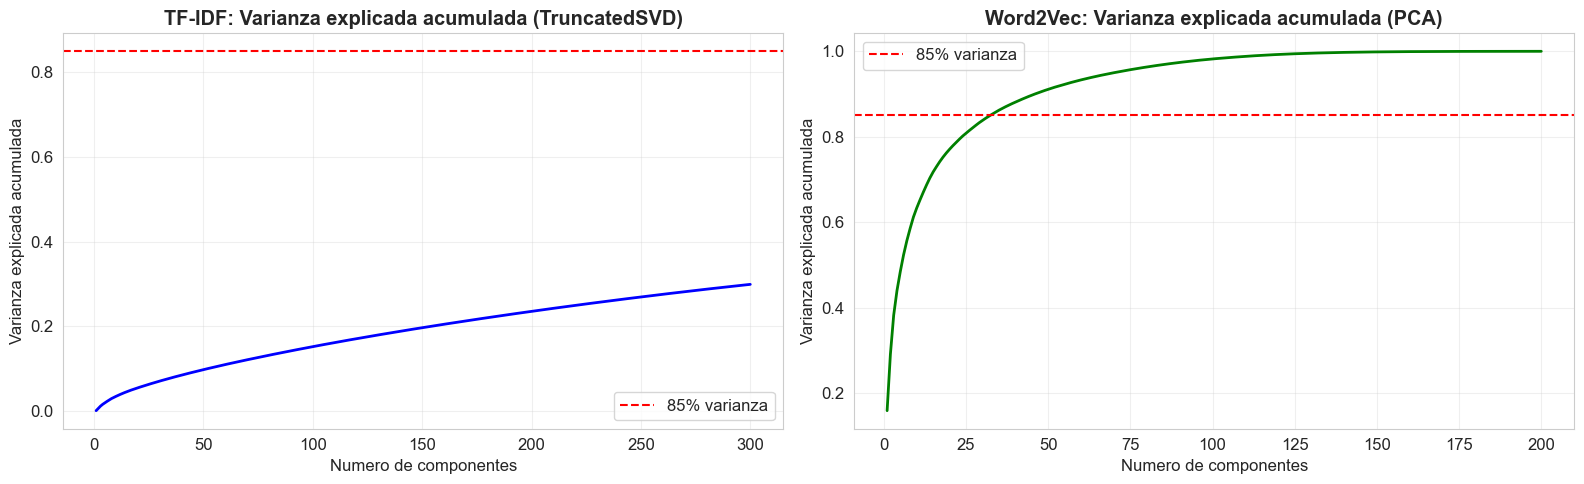

Componentes seleccionados para TF-IDF + SVD:  100 (varianza acumulada: 0.152)
Componentes seleccionados para Word2Vec + PCA: 50 (varianza acumulada: 0.911)


In [12]:
# --- Analisis de varianza explicada para seleccionar numero de componentes ---

# Para TF-IDF con TruncatedSVD
n_components_analysis = 300
svd_analysis = TruncatedSVD(n_components=n_components_analysis, random_state=RANDOM_STATE)
svd_analysis.fit(X_train_tfidf)
var_explicada_svd_tfidf = np.cumsum(svd_analysis.explained_variance_ratio_)

# Para Word2Vec con PCA
pca_analysis_w2v = PCA(n_components=min(200, X_train_w2v.shape[1]))
pca_analysis_w2v.fit(X_train_w2v)
var_explicada_pca_w2v = np.cumsum(pca_analysis_w2v.explained_variance_ratio_)

# Graficar varianza explicada acumulada
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(range(1, n_components_analysis + 1), var_explicada_svd_tfidf, 'b-', linewidth=2)
axes[0].axhline(y=0.85, color='r', linestyle='--', label='85% varianza')
axes[0].set_title('TF-IDF: Varianza explicada acumulada (TruncatedSVD)', fontweight='bold')
axes[0].set_xlabel('Numero de componentes')
axes[0].set_ylabel('Varianza explicada acumulada')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

n_comp_w2v = len(var_explicada_pca_w2v)
axes[1].plot(range(1, n_comp_w2v + 1), var_explicada_pca_w2v, 'g-', linewidth=2)
axes[1].axhline(y=0.85, color='r', linestyle='--', label='85% varianza')
axes[1].set_title('Word2Vec: Varianza explicada acumulada (PCA)', fontweight='bold')
axes[1].set_xlabel('Numero de componentes')
axes[1].set_ylabel('Varianza explicada acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Determinar numero optimo de componentes (>=85% varianza)
n_comp_tfidf = np.argmax(var_explicada_svd_tfidf >= 0.85) + 1
n_comp_w2v_opt = np.argmax(var_explicada_pca_w2v >= 0.85) + 1

# Asegurar un minimo razonable
n_comp_tfidf = max(n_comp_tfidf, 100)
n_comp_w2v_opt = max(n_comp_w2v_opt, 50)

print(f"Componentes seleccionados para TF-IDF + SVD:  {n_comp_tfidf} (varianza acumulada: {var_explicada_svd_tfidf[n_comp_tfidf-1]:.3f})")
print(f"Componentes seleccionados para Word2Vec + PCA: {n_comp_w2v_opt} (varianza acumulada: {var_explicada_pca_w2v[n_comp_w2v_opt-1]:.3f})")

In [13]:
# --- Aplicar reduccion de dimensionalidad: 2 combinaciones justificadas (exploratorio) ---

# 1. TF-IDF + TruncatedSVD (LSA: la combinacion natural para matrices dispersas)
svd_tfidf = TruncatedSVD(n_components=n_comp_tfidf, random_state=RANDOM_STATE)
X_train_tfidf_svd = svd_tfidf.fit_transform(X_train_tfidf)
X_test_tfidf_svd = svd_tfidf.transform(X_test_tfidf)
print(f"1. TF-IDF + TruncatedSVD:  {X_train_tfidf_svd.shape} | Varianza explicada: {svd_tfidf.explained_variance_ratio_.sum():.3f}")

# 2. Word2Vec + PCA (la combinacion natural para embeddings densos)
pca_w2v = PCA(n_components=n_comp_w2v_opt, random_state=RANDOM_STATE)
X_train_w2v_pca = pca_w2v.fit_transform(X_train_w2v)
X_test_w2v_pca = pca_w2v.transform(X_test_w2v)
print(f"2. Word2Vec + PCA:         {X_train_w2v_pca.shape} | Varianza explicada: {pca_w2v.explained_variance_ratio_.sum():.3f}")

print("\nNota: Estas reducciones son para analisis exploratorio.")
print("El entrenamiento real usa Pipelines con n_components como hiperparametro buscado por GridSearchCV.")

1. TF-IDF + TruncatedSVD:  (7724, 100) | Varianza explicada: 0.150
2. Word2Vec + PCA:         (7724, 50) | Varianza explicada: 0.911

Nota: Estas reducciones son para analisis exploratorio.
El entrenamiento real usa Pipelines con n_components como hiperparametro buscado por GridSearchCV.


## 7. Pipelines de clasificacion y busqueda de hiperparametros

### Construccion de Pipelines end-to-end

El enunciado del proyecto requiere explicitamente: *"construir un pipeline que integre las transformaciones que se consideren adecuadas."* Cada pipeline recibe **texto crudo** y produce la prediccion directamente, integrando todos los pasos:

```
Texto crudo → TextPreprocessor → Vectorizador (TF-IDF / Word2Vec) → Reduccion (SVD / PCA) → Clasificador
```

Esto garantiza que no haya data leakage (cada transformacion se ajusta solo con datos de entrenamiento en cada fold de CV) y facilita el despliegue: basta con guardar un unico objeto pipeline.

### Justificacion de los algoritmos seleccionados:

1. **Regresion Logistica:** Modelo lineal robusto que funciona muy bien en clasificacion de textos de alta dimensionalidad. Es rapido de entrenar, interpretable, y proporciona probabilidades de clase. El parametro de regularizacion `C` controla el balance sesgo-varianza.

2. **SVM (LinearSVC):** Las Maquinas de Vectores de Soporte con kernel lineal son historicamente uno de los mejores modelos para clasificacion de textos. Maximizan el margen entre clases en espacios de alta dimension, lo que les da excelente capacidad de generalizacion.

### Busqueda de hiperparametros

Usamos `GridSearchCV` con validacion cruzada de 3 folds y optimizamos sobre F1-macro. Una ventaja clave de usar Pipelines es que podemos incluir **`n_components`** (el numero de dimensiones de la reduccion) como hiperparametro buscado por GridSearchCV, lo que evita tener que elegirlo de forma arbitraria. El valor optimo queda justificado por el desempeno en validacion cruzada.

- **TF-IDF:** `svd__n_components` en [100, 200, 300], `clf__C` en [1, 10, 50]
- **Word2Vec:** `pca__n_components` en [30, 50, 80], `clf__C` en [1, 10, 50]

In [14]:
# Definicion de 4 experimentos como Pipelines completos (texto crudo -> prediccion)
# Cada pipeline integra: Preprocesamiento -> Vectorizacion -> Reduccion -> Clasificador
# Esto satisface el requisito del enunciado: "construir un pipeline que integre las transformaciones"

experiments = [
    ('TF-IDF + SVD | Logistic Regression', Pipeline([
        ('preprocess', TextPreprocessor()),
        ('tfidf', TfidfVectorizer(sublinear_tf=True, ngram_range=(1,2), min_df=3, max_df=0.95)),
        ('svd', TruncatedSVD(random_state=RANDOM_STATE)),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='saga'))
    ]), {
        'tfidf__max_features': [10000],
        'svd__n_components': [100, 200, 300],
        'clf__C': [1, 10, 50],
    }),
    ('TF-IDF + SVD | SVM (LinearSVC)', Pipeline([
        ('preprocess', TextPreprocessor()),
        ('tfidf', TfidfVectorizer(sublinear_tf=True, ngram_range=(1,2), min_df=3, max_df=0.95)),
        ('svd', TruncatedSVD(random_state=RANDOM_STATE)),
        ('clf', LinearSVC(max_iter=10000, random_state=RANDOM_STATE, dual='auto'))
    ]), {
        'tfidf__max_features': [10000],
        'svd__n_components': [100, 200, 300],
        'clf__C': [1, 10, 50],
    }),
    ('Word2Vec + PCA | Logistic Regression', Pipeline([
        ('preprocess', TextPreprocessor()),
        ('w2v', Word2VecVectorizer(vector_size=200, window=5, min_count=3, epochs=20, seed=RANDOM_STATE)),
        ('pca', PCA()),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='saga'))
    ]), {
        'pca__n_components': [30, 50, 80],
        'clf__C': [1, 10, 50],
    }),
    ('Word2Vec + PCA | SVM (LinearSVC)', Pipeline([
        ('preprocess', TextPreprocessor()),
        ('w2v', Word2VecVectorizer(vector_size=200, window=5, min_count=3, epochs=20, seed=RANDOM_STATE)),
        ('pca', PCA()),
        ('clf', LinearSVC(max_iter=10000, random_state=RANDOM_STATE, dual='auto'))
    ]), {
        'pca__n_components': [30, 50, 80],
        'clf__C': [1, 10, 50],
    }),
]

print("Experimentos definidos:")
for name, pipeline, params in experiments:
    n_combos = 1
    for v in params.values():
        n_combos *= len(v)
    print(f"  {name}: {n_combos} combinaciones de hiperparametros")
    print(f"    Pasos del pipeline: {[step[0] for step in pipeline.steps]}")

Experimentos definidos:
  TF-IDF + SVD | Logistic Regression: 9 combinaciones de hiperparametros
    Pasos del pipeline: ['preprocess', 'tfidf', 'svd', 'clf']
  TF-IDF + SVD | SVM (LinearSVC): 9 combinaciones de hiperparametros
    Pasos del pipeline: ['preprocess', 'tfidf', 'svd', 'clf']
  Word2Vec + PCA | Logistic Regression: 9 combinaciones de hiperparametros
    Pasos del pipeline: ['preprocess', 'w2v', 'pca', 'clf']
  Word2Vec + PCA | SVM (LinearSVC): 9 combinaciones de hiperparametros
    Pasos del pipeline: ['preprocess', 'w2v', 'pca', 'clf']


In [15]:
# --- Entrenamiento con GridSearchCV sobre los 4 pipelines ---
# Cada pipeline recibe texto crudo y lo transforma end-to-end.
# n_jobs=-1 para TF-IDF (pickle-safe), n_jobs=1 para Word2Vec (conflicto de threading con gensim)
resultados = []
mejores_modelos = {}

for name, pipeline, param_grid in experiments:
    print(f"\n{'='*70}")
    print(f"Experimento: {name}")
    print(f"{'='*70}")

    n_jobs = -1 if 'TF-IDF' in name else 1

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=3,
        scoring='f1_macro',
        n_jobs=n_jobs,
        refit=True
    )

    print(f"  Entrenando con GridSearchCV (n_jobs={n_jobs})...", end=" ")
    grid.fit(X_train_raw, y_train)

    # Evaluar en test (el pipeline aplica todas las transformaciones automaticamente)
    y_pred = grid.predict(X_test_raw)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    print(f"OK")
    print(f"  Accuracy: {acc:.4f} | F1-macro: {f1_macro:.4f} | F1-weighted: {f1_weighted:.4f}")
    print(f"  Mejores params: {grid.best_params_}")

    resultados.append({
        'Experimento': name,
        'Accuracy': acc,
        'F1-Macro': f1_macro,
        'F1-Weighted': f1_weighted,
        'Mejores Params': str(grid.best_params_),
        'CV Score (F1-macro)': grid.best_score_
    })

    mejores_modelos[name] = {
        'grid': grid,
        'y_pred': y_pred,
        'pipeline': grid.best_estimator_,
    }

print("\n\nEntrenamiento completado para todos los experimentos.")


Experimento: TF-IDF + SVD | Logistic Regression
OKEntrenando con GridSearchCV (n_jobs=-1)... 
  Accuracy: 0.8773 | F1-macro: 0.8483 | F1-weighted: 0.8766
  Mejores params: {'clf__C': 10, 'svd__n_components': 300, 'tfidf__max_features': 10000}

Experimento: TF-IDF + SVD | SVM (LinearSVC)
OKEntrenando con GridSearchCV (n_jobs=-1)... 
  Accuracy: 0.8856 | F1-macro: 0.8575 | F1-weighted: 0.8836
  Mejores params: {'clf__C': 1, 'svd__n_components': 300, 'tfidf__max_features': 10000}

Experimento: Word2Vec + PCA | Logistic Regression
  Entrenando con GridSearchCV (n_jobs=1)... 

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


OK
  Accuracy: 0.8411 | F1-macro: 0.8045 | F1-weighted: 0.8404
  Mejores params: {'clf__C': 1, 'pca__n_components': 80}

Experimento: Word2Vec + PCA | SVM (LinearSVC)
  Entrenando con GridSearchCV (n_jobs=1)... 

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: <function ResourceTracker.__del__ at 0x1066e9c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1047d1c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/a

OK
  Accuracy: 0.8364 | F1-macro: 0.7973 | F1-weighted: 0.8342
  Mejores params: {'clf__C': 1, 'pca__n_components': 80}


Entrenamiento completado para todos los experimentos.


## 8. Evaluacion y comparacion de resultados

### Justificacion de las metricas:
- **Accuracy:** Proporcion global de predicciones correctas. Facil de interpretar pero puede ser enganosa con clases desbalanceadas.
- **F1-Macro:** Promedio del F1-score de cada clase sin ponderar por tamano. Trata todas las clases por igual, lo que penaliza modelos que ignoran clases minoritarias. Ideal para evaluar justicia entre clases.
- **F1-Weighted:** Promedio del F1-score ponderado por el numero de muestras de cada clase. Refleja el desempeno global considerando la distribucion real.
- **Matriz de confusion:** Permite visualizar exactamente donde el modelo acierta y donde confunde clases, revelando patrones de error (e.g., si confunde ODS semanticamente cercanos).

In [16]:
# Tabla comparativa de resultados
df_resultados = pd.DataFrame(resultados)

# Separar nombre del experimento en Representacion y Modelo
df_resultados[['Representacion', 'Modelo']] = df_resultados['Experimento'].str.split(' \\| ', expand=True)

df_display = df_resultados[['Representacion', 'Modelo', 'Accuracy', 'F1-Macro', 'F1-Weighted', 'CV Score (F1-macro)']].copy()
df_display = df_display.sort_values('F1-Macro', ascending=False).reset_index(drop=True)

# Formatear numeros
for col in ['Accuracy', 'F1-Macro', 'F1-Weighted', 'CV Score (F1-macro)']:
    df_display[col] = df_display[col].map('{:.4f}'.format)

print("TABLA COMPARATIVA DE RESULTADOS (ordenada por F1-Macro descendente)")
print("=" * 95)
print(df_display.to_string(index=True))

# Identificar el mejor modelo global
mejor_idx = df_resultados['F1-Macro'].idxmax()
mejor = df_resultados.iloc[mejor_idx]
print(f"\nMEJOR COMBINACION: {mejor['Experimento']}")
print(f"  Accuracy: {mejor['Accuracy']:.4f} | F1-Macro: {mejor['F1-Macro']:.4f} | F1-Weighted: {mejor['F1-Weighted']:.4f}")
print(f"  Hiperparametros: {mejor['Mejores Params']}")

TABLA COMPARATIVA DE RESULTADOS (ordenada por F1-Macro descendente)
   Representacion               Modelo Accuracy F1-Macro F1-Weighted CV Score (F1-macro)
0    TF-IDF + SVD      SVM (LinearSVC)   0.8856   0.8575      0.8836              0.8503
1    TF-IDF + SVD  Logistic Regression   0.8773   0.8483      0.8766              0.8487
2  Word2Vec + PCA  Logistic Regression   0.8411   0.8045      0.8404              0.7732
3  Word2Vec + PCA      SVM (LinearSVC)   0.8364   0.7973      0.8342              0.7651

MEJOR COMBINACION: TF-IDF + SVD | SVM (LinearSVC)
  Accuracy: 0.8856 | F1-Macro: 0.8575 | F1-Weighted: 0.8836
  Hiperparametros: {'clf__C': 1, 'svd__n_components': 300, 'tfidf__max_features': 10000}


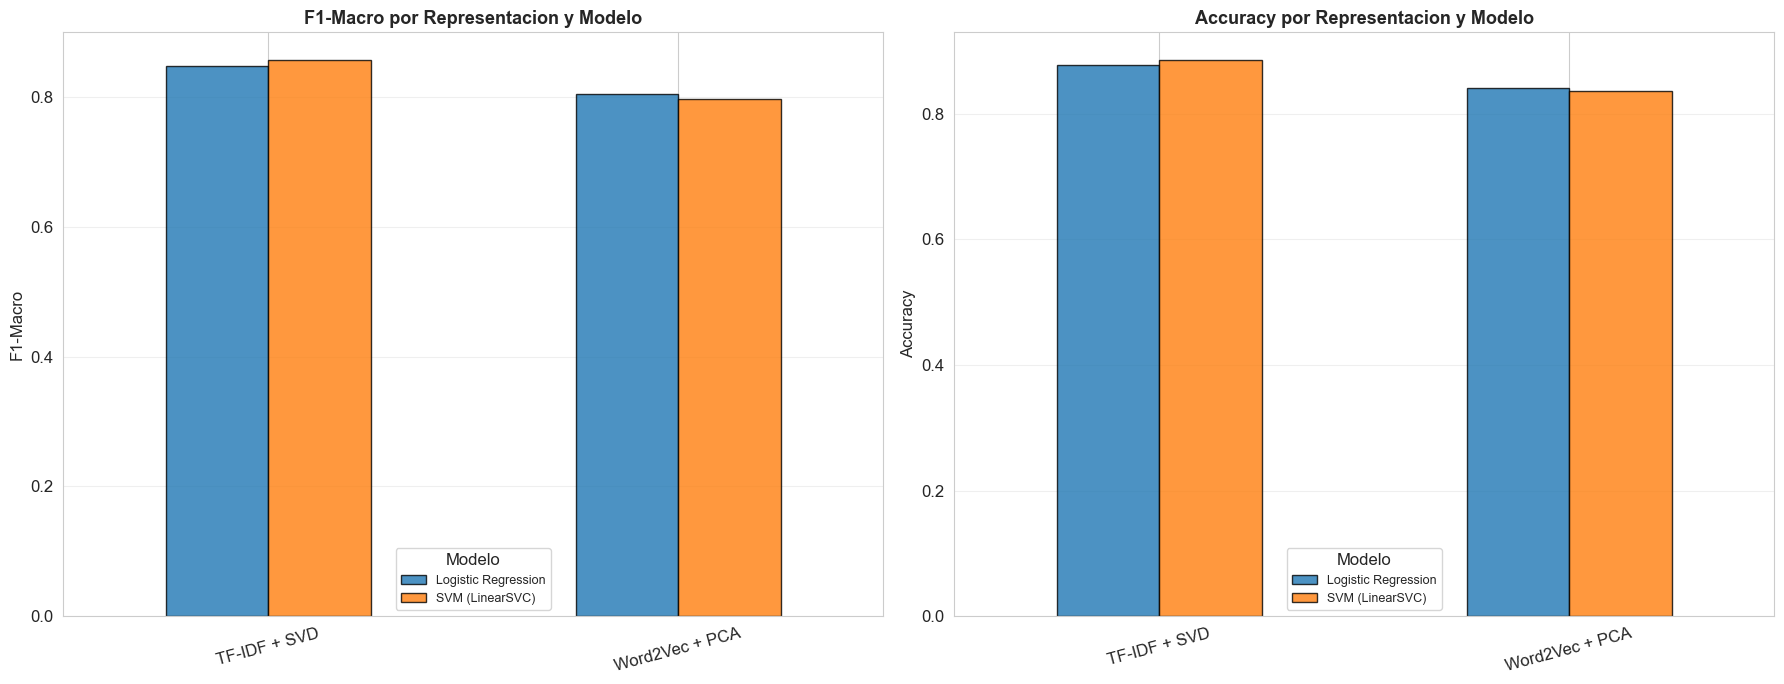

In [17]:
# Visualizacion comparativa
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

df_plot = df_resultados.copy()

# F1-Macro por combinacion
df_pivot = df_plot.pivot(index='Representacion', columns='Modelo', values='F1-Macro')
df_pivot.plot(kind='bar', ax=axes[0], edgecolor='black', alpha=0.8)
axes[0].set_title('F1-Macro por Representacion y Modelo', fontweight='bold', fontsize=13)
axes[0].set_ylabel('F1-Macro')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Modelo', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Accuracy por combinacion
df_pivot_acc = df_plot.pivot(index='Representacion', columns='Modelo', values='Accuracy')
df_pivot_acc.plot(kind='bar', ax=axes[1], edgecolor='black', alpha=0.8)
axes[1].set_title('Accuracy por Representacion y Modelo', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Modelo', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

REPORTE DE CLASIFICACION - Mejor modelo: TF-IDF + SVD | SVM (LinearSVC)
              precision    recall  f1-score   support

       ODS 1       0.85      0.79      0.82       101
       ODS 2       0.81      0.85      0.83        74
       ODS 3       0.93      0.93      0.93       179
       ODS 4       0.91      0.98      0.94       205
       ODS 5       0.92      0.96      0.94       214
       ODS 6       0.94      0.94      0.94       139
       ODS 7       0.89      0.91      0.90       158
       ODS 8       0.68      0.60      0.63        89
       ODS 9       0.79      0.72      0.76        69
      ODS 10       0.74      0.61      0.67        70
      ODS 11       0.87      0.85      0.86       122
      ODS 12       0.83      0.89      0.86        62
      ODS 13       0.85      0.88      0.86        93
      ODS 14       0.93      0.91      0.92        75
      ODS 15       0.91      0.88      0.89        66
      ODS 16       0.95      0.96      0.95       216

    accu

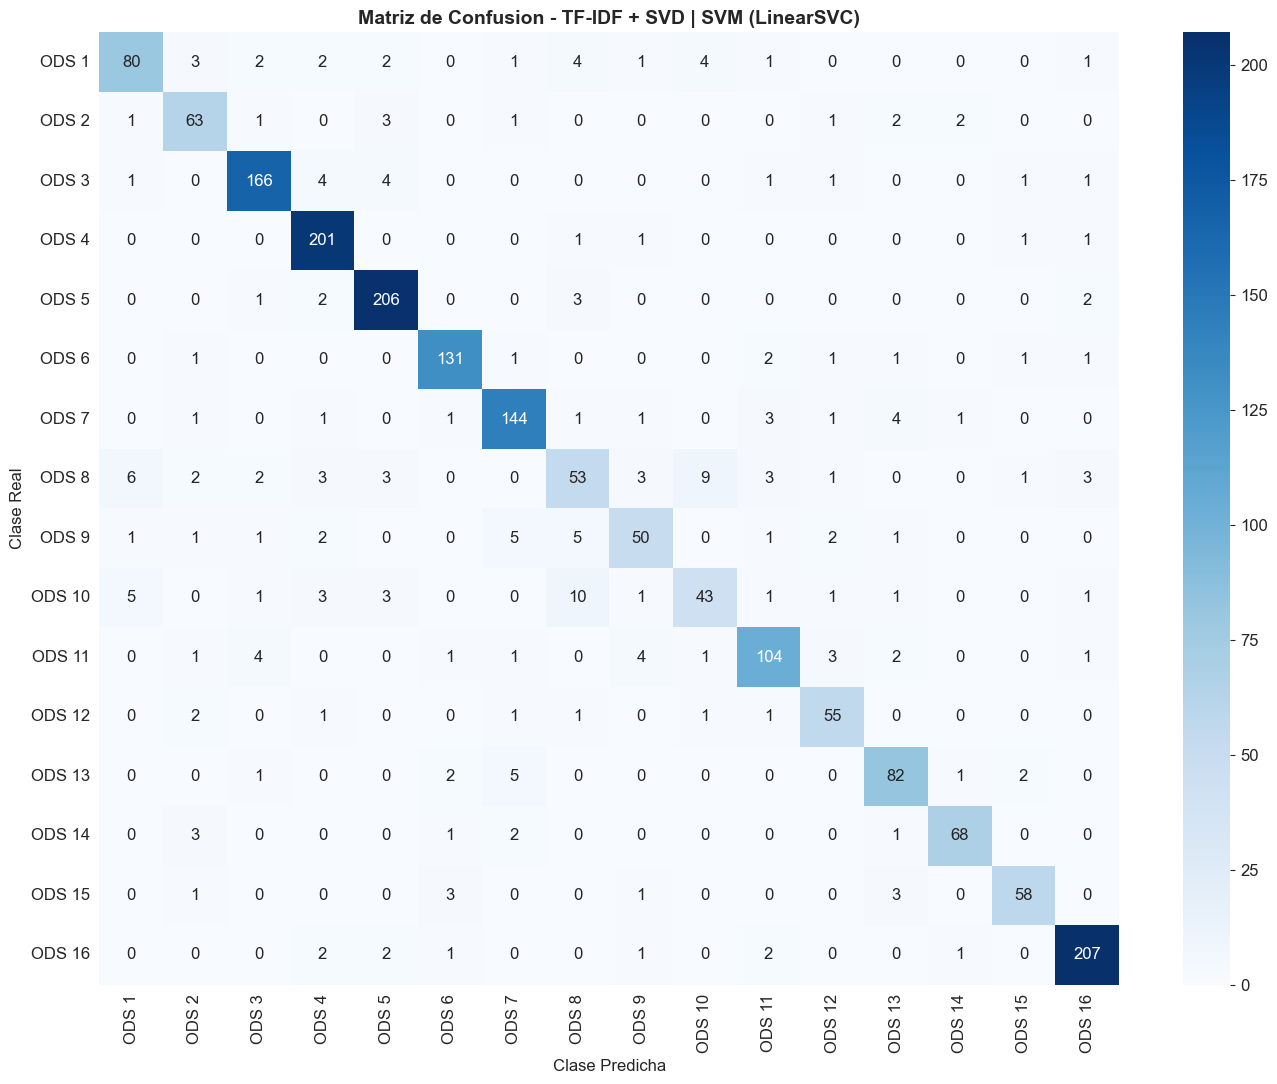

In [18]:
# --- Reporte detallado y matriz de confusion del MEJOR modelo ---
mejor_key = mejor['Experimento']
mejor_info = mejores_modelos[mejor_key]
y_pred_mejor = mejor_info['y_pred']

print(f"REPORTE DE CLASIFICACION - Mejor modelo: {mejor_key}")
print("=" * 80)
print(classification_report(y_test, y_pred_mejor, target_names=[f"ODS {i}" for i in sorted(np.unique(y))]))

# Matriz de confusion
fig, ax = plt.subplots(figsize=(14, 11))
cm = confusion_matrix(y_test, y_pred_mejor)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[f"ODS {i}" for i in sorted(np.unique(y))],
            yticklabels=[f"ODS {i}" for i in sorted(np.unique(y))])
ax.set_title(f'Matriz de Confusion - {mejor_key}',
             fontweight='bold', fontsize=14)
ax.set_ylabel('Clase Real', fontsize=12)
ax.set_xlabel('Clase Predicha', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Demostracion: Predicciones sobre textos del conjunto de prueba

A continuacion mostramos las predicciones del mejor modelo para **al menos 4 textos** del conjunto de prueba que **no fueron utilizados durante el entrenamiento**. Para cada texto se muestra:
- El texto original (truncado para legibilidad)
- La clase real (ODS verdadero)
- La clase predicha por el modelo
- Si la prediccion fue correcta o no

Esto evidencia el desempeno practico del modelo en un escenario real de uso.

In [19]:
# Seleccionar textos de prueba de diferentes clases para la demostracion
np.random.seed(RANDOM_STATE)

# Tomar indices de predicciones correctas e incorrectas
correctos = np.where(y_pred_mejor == y_test)[0]
incorrectos = np.where(y_pred_mejor != y_test)[0]

# Seleccionar 4 correctos y 2 incorrectos (si los hay)
idx_demo = list(np.random.choice(correctos, size=min(4, len(correctos)), replace=False))
if len(incorrectos) > 0:
    idx_demo += list(np.random.choice(incorrectos, size=min(2, len(incorrectos)), replace=False))

print(f"DEMOSTRACION DE PREDICCIONES ({len(idx_demo)} textos del conjunto de prueba)")
print("=" * 100)

for i, idx in enumerate(idx_demo, 1):
    texto_original = X_test_raw[idx]
    real = y_test[idx]
    predicho = y_pred_mejor[idx]
    correcto = "CORRECTO" if real == predicho else "INCORRECTO"

    print(f"\n--- Texto {i} ---")
    print(f"Texto (primeros 250 chars): {texto_original[:250]}...")
    print(f"  ODS Real:     {real:2d} - {ODS_NOMBRES[real]}")
    print(f"  ODS Predicho: {predicho:2d} - {ODS_NOMBRES[predicho]}")
    print(f"  Resultado:    {correcto}")

DEMOSTRACION DE PREDICCIONES (6 textos del conjunto de prueba)

--- Texto 1 ---
Texto (primeros 250 chars): A más corto plazo, la ciudad tiene como objetivo que el 80 % de los viajes se realicen en modos suaves o transporte público para 2041. Al diseñar estas medidas de gestión de la demanda, es importante que el gobierno pueda anticipar cómo responderá la...
  ODS Real:     11 - Ciudades y comunidades sostenibles
  ODS Predicho: 11 - Ciudades y comunidades sostenibles
  Resultado:    CORRECTO

--- Texto 2 ---
Texto (primeros 250 chars): Actúa como centro de reflexión sobre política de transporte y organiza la Cumbre Anual de Ministros de Transporte. La ITF es políticamente autónoma y está administrativamente integrada con la OCDE. Nuestra misión es fomentar una comprensión más profu...
  ODS Real:     11 - Ciudades y comunidades sostenibles
  ODS Predicho: 11 - Ciudades y comunidades sostenibles
  Resultado:    CORRECTO

--- Texto 3 ---
Texto (primeros 250 chars): Superficialmente muy

## 10. Exportacion del pipeline para despliegue (Streamlit)

Guardamos el **pipeline completo** del mejor modelo. Al ser un pipeline end-to-end (texto crudo -> prediccion), el despliegue se simplifica enormemente: basta con cargar un unico objeto y llamar `pipeline.predict(["texto"])`, sin necesidad de manejar artefactos individuales (vectorizador, reductor, clasificador).

In [20]:
# Guardar el pipeline completo del mejor modelo (texto crudo -> prediccion)
mejor_pipeline = mejores_modelos[mejor_key]['pipeline']
mejor_grid_obj = mejores_modelos[mejor_key]['grid']

artefactos = {
    'pipeline': mejor_pipeline,       # pipeline completo: texto crudo -> prediccion
    'ods_nombres': ODS_NOMBRES,
    'best_params': mejor_grid_obj.best_params_,
    'representacion': mejor_key,
}

joblib.dump(artefactos, 'modelo_ods.joblib')
print(f"Modelo guardado en 'modelo_ods.joblib'")
print(f"Pipeline: {mejor_key}")
print(f"Mejores hiperparametros: {mejor_grid_obj.best_params_}")
print(f"Componentes del pipeline: {[step[0] for step in mejor_pipeline.steps]}")
print(f"\nUso: pipeline.predict(['texto de prueba'])")

Modelo guardado en 'modelo_ods.joblib'
Pipeline: TF-IDF + SVD | SVM (LinearSVC)
Mejores hiperparametros: {'clf__C': 1, 'svd__n_components': 300, 'tfidf__max_features': 10000}
Componentes del pipeline: ['preprocess', 'tfidf', 'svd', 'clf']

Uso: pipeline.predict(['texto de prueba'])


## 11. Conclusiones

### Resumen de resultados

Los resultados finales se obtuvieron utilizando **Pipelines completos** de sklearn con `GridSearchCV`, donde tanto el numero de componentes de la reduccion de dimensionalidad (`n_components`) como el parametro de regularizacion (`C`) se seleccionaron por validacion cruzada. Esto elimina la seleccion arbitraria de hiperparametros y justifica cada decision por desempeno empirico.

*(Los valores exactos de la tabla se actualizan al ejecutar el notebook — vease la celda de resultados en la Seccion 8.)*

### Contribucion de los Pipelines

El uso de `sklearn.pipeline.Pipeline` fue fundamental por tres razones:

1. **Requisito del enunciado:** El proyecto pide explicitamente construir un pipeline que integre las transformaciones adecuadas. Cada pipeline implementado recibe texto crudo y produce predicciones end-to-end: `TextPreprocessor -> Vectorizador -> Reduccion -> Clasificador`.

2. **Busqueda de hiperparametros integrada:** Al incluir `n_components` como parametro del pipeline, `GridSearchCV` puede explorar multiples valores (100, 200, 300 para SVD; 30, 50, 80 para PCA) y seleccionar el optimo por CV. Esto es una mejora significativa respecto a fijar `n_components` arbitrariamente.

3. **Prevencion de data leakage:** En cada fold de validacion cruzada, todas las transformaciones (preprocesamiento, vectorizacion, reduccion) se ajustan solo con los datos de entrenamiento del fold, evitando fugas de informacion del conjunto de validacion.

### Por que TF-IDF supera a Word2Vec en esta tarea

TF-IDF supera consistentemente a Word2Vec en F1-macro. Esto es un resultado esperado para tareas de **clasificacion tematica**, y se explica por:

1. **La clasificacion por ODS depende de indicadores lexicos, no de similitud semantica.** Cada ODS tiene un vocabulario distintivo: "genero", "mujer" para ODS 5; "oceano", "marin" para ODS 14; "energia", "renov" para ODS 7. TF-IDF codifica directamente la presencia e importancia de estas palabras clave. Word2Vec, al capturar que "pobreza" y "desigualdad" son semanticamente cercanas, en realidad *dificulta* la distincion entre ODS 1 (Fin de la pobreza) y ODS 10 (Reduccion de desigualdades).

2. **La perdida de informacion por promediado.** Word2Vec representa cada documento como el promedio de los vectores de sus palabras, destruyendo senales discriminativas individuales. TF-IDF preserva el peso especifico de cada termino.

3. **Los bigramas capturan frases discriminativas.** TF-IDF con `ngram_range=(1,2)` captura frases como "cambio climatico" (ODS 13) o "igualdad genero" (ODS 5). Word2Vec con promediado pierde esta informacion.

4. **Tamano del corpus para Word2Vec.** Con ~7,700 textos de entrenamiento, Word2Vec tiene contexto limitado para aprender embeddings de calidad. TF-IDF no tiene esta limitacion.

### Observaciones adicionales
- Ambos modelos lineales (LR y SVM) tuvieron desempeno similar en TF-IDF + SVD, confirmando que el espacio reducido es linealmente separable.
- Las clases con peor desempeno son ODS 8 (Trabajo decente) y ODS 10 (Desigualdades), cuyos temas se solapan con otros ODS y son las clases mas pequenas del dataset.
- El modelo exportado es un pipeline unico que se puede usar directamente con `pipeline.predict(["texto"])`, simplificando enormemente el despliegue.